### Purpose (why we do this)

* We want to find **when** changepoints (CPs) tend to happen within a 24-hour day and whether they cluster around **two preferred times** (two “centers of mass”).
* We also want to measure how **clear/tight** those two times are (i.e., do CPs bunch tightly there or spread out?), so we can later compare **females vs males**.

### Technique (how we do it)

1. **Detect CPs per day** for one animal (using `ruptures`) and collect all CP timestamps.
2. **Map each CP to the 24-hour clock** by converting minute-of-day to an angle on the circle (0 to (2\pi)).
3. **Visualize** with a 24-bin histogram (by hour) and plot it as a **circular (polar) bar chart** to see daily timing patterns.
4. **Fit a 2-component von Mises mixture** (the circular analog of a 2-Gaussian mixture) to the raw CP angles:

   * This estimates **two mean directions** ((\mu_1,\mu_2)) = the two centers of mass.
   * It also estimates **concentrations** ((\kappa_1,\kappa_2)) = how **tight/clear** each center is (higher (\kappa) = sharper).
5. **Quantify clarity & separation** using (\kappa_1,\kappa_2) and the angular distance between (\mu_1) and (\mu_2).
6. **Check non-randomness** (optional but recommended) with circular uniformity tests (e.g., Rayleigh/Hermans–Rasson) to show CP times aren’t uniform around the clock.

**In short:** detect CPs → put them on a 24-h circle → fit **two** circular centers → use their **tightness** and **separation** to measure “clarity,” then compare those metrics between sexes.



* For each time/angle ( \theta ), we map it to a **point on the unit circle**:
  ((x,y) = (\cos\theta,; \sin\theta)).
  Each point has length 1 (that’s the “unit” part).

* Then we **average those vectors** across all data points:
  (\bar C = \text{mean}(\cos\theta_i),; \bar S = \text{mean}(\sin\theta_i)).

* The **direction** of the average vector ((\bar C,\bar S)) gives the mean time ( \mu = \text{atan2}(\bar S,\bar C) ).
  The **length** ( \bar R = \sqrt{\bar C^2+\bar S^2} ) tells how concentrated the data are (near 1 = tight; near 0 = scattered).

That’s the whole trick: convert to unit-circle points → average the vectors → read off direction (mean) and length (spread).


In [1]:
# Comment: uncomment the next two lines in a fresh environment if these packages aren't installed
# Comment: !pip install numpy pandas matplotlib ruptures scikit-learn scipy

# Comment: import core numerics & data handling
import numpy as np
import pandas as pd

# Comment: import plotting
import matplotlib.pyplot as plt

# Comment: import changepoint detection library
import ruptures as rpt

# Comment: import tools for clustering init and von Mises math
from sklearn.cluster import KMeans
from scipy.stats import vonmises

# Comment: set matplotlib to display plots nicely in notebooks
plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [3]:
# Comment: read the CSV (no datetime needed; we have 'time (min)' as a counter)
df = pd.read_csv('mice data.xlsx - FemTemp.csv')


In [4]:
df

,time (min),fem1,fem2,fem3,fem4,fem5,fem6,fem7,fem8,fem9,fem10,fem11,fem12,fem13,fem14
0,1,38.20,37.31,37.03,37.20,37.17,37.44,37.33,36.58,37.41,37.18,37.27,38.31,36.51,36.44
1,2,38.18,37.43,37.01,37.22,37.25,37.49,37.28,36.75,37.39,37.14,37.32,38.43,36.61,36.43
2,3,38.20,37.64,36.98,37.25,37.47,37.52,37.34,36.82,37.24,37.02,37.29,38.46,36.69,36.47
3,4,38.28,37.71,36.99,37.25,37.51,37.51,37.37,36.86,37.27,36.96,37.27,38.46,36.73,36.58
4,5,38.35,37.76,37.02,37.24,37.51,37.59,37.34,36.91,37.42,36.69,37.27,38.51,36.73,36.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11515,11516,37.00,37.01,37.69,37.60,36.74,37.52,37.92,37.45,37.06,36.68,37.38,38.09,36.57,36.58
11516,11517,37.21,37.01,37.80,37.58,36.78,37.57,37.89,37.53,37.06,36.67,37.31,38.21,36.57,36.58
11517,11518,37.30,37.05,37.87,37.54,36.86,37.55,37.96,37.55,37.13,36.67,37.23,38.26,36.56,36.52
11518,11519,37.30,37.14,37.90,37.49,36.89,37.52,38.04,37.52,37.19,36.72,37.16,38.26,36.55,36.52


In [5]:
ANIMAL_COL = "fem1"

In [6]:
time_min = df["time (min)"].astype(int).values  # 1..11520 for 8 days
temp = df[ANIMAL_COL].astype(float).values  

In [10]:
time_min

array([    1,     2,     3, ..., 11518, 11519, 11520])

In [7]:
assert len(time_min) % 1440 == 0, "Expected full days (multiples of 1440 minutes)."


In [9]:
n_days = len(time_min) // 1440    
print(f"Data contains {n_days} full days of minute-level data for animal '{ANIMAL_COL}'.")

Data contains 8 full days of minute-level data for animal 'fem1'.


### STEP 1 — Define day index and minute-of-day
 derive day_id in 0..(n_days-1) and minute_of_day in 0..1439 using the minute counter.

In [11]:
# Comment: convert the 1-based minute counter to 0-based for easy modulo arithmetic
t0 = time_min - 1                              # now 0..(11520-1)

# Comment: compute day_id by integer dividing by 1440
day_id = t0 // 1440                            # 0..(n_days-1)

# Comment: compute minute_of_day by modulo 1440
minute_of_day = t0 % 1440                      # 0..1439

In [12]:
print(f"day_id: {day_id[:10]} ... {day_id[-10:]}")
print(f"minute_of_day: {minute_of_day[:10]} ... {minute_of_day[-10:]}")


day_id: [0 0 0 0 0 0 0 0 0 0] ... [7 7 7 7 7 7 7 7 7 7]
minute_of_day: [0 1 2 3 4 5 6 7 8 9] ... [1430 1431 1432 1433 1434 1435 1436 1437 1438 1439]


### STEP 2 — Detect ALL change points per day (not capped)
use ruptures (PELT) with RBF cost; tune min_size and penalty to avoid over-segmentation.


In [13]:
CP_MODEL = "rbf"   # 'rbf' is flexible for shape/level changes; alternatives: 'normal', 'l2'
MIN_SIZE = 30      # minimum segment length in minutes (helps suppress tiny segments)
PENALTY = 12       # penalty for adding CPs; increase to reduce the number of CPs

In [14]:
# Comment: prepare list to collect CP minute_of_day values across all days
cp_minutes_all = []  # this will store minute-of-day (0..1439) for each detected CP

In [15]:
# Comment: loop over each day and run changepoint detection independently
for d in range(n_days):
    # Comment: find indices for this day
    mask = (day_id == d)
    # Comment: extract the day's temperature vector (length should be 1440)
    x = temp[mask]
    # Comment: set up PELT algorithm with chosen model and min_size
    algo = rpt.Pelt(model=CP_MODEL, min_size=MIN_SIZE).fit(x)
    # Comment: predict change points using the penalty; result are 1-based end indices of segments
    cps = algo.predict(pen=PENALTY)
    # Comment: convert to 0-based CP locations and drop the terminal index (length of the day)
    day_len = len(x)  # should be 1440
    cutpoints = [idx for idx in cps if idx < day_len]  # keep internal CPs only
    # Comment: record each CP as its minute-of-day (already aligned because each day starts at minute 0)
    cp_minutes_all.extend(cutpoints)

In [16]:
cp_minutes_all = np.array(cp_minutes_all, dtype=int)


In [18]:
print(f"# Total CPs found (all days for {ANIMAL_COL}): {cp_minutes_all.size}")

# Total CPs found (all days for fem1): 68


### STEP 3 — Bucket CPs into hours and normalize
create a 24-bin histogram by hour (0..23), then normalize to rate-per-day to avoid day-count bias.


In [19]:
# Comment: convert minute-of-day CPs to hour-of-day integers (0..23)
cp_hours = (cp_minutes_all // 60).astype(int)  # 0..23

In [20]:
cp_hours

array([ 3,  4,  8, 11, 13, 13, 22, 23,  4,  5,  9, 11, 12, 17, 18, 21, 23,
        2,  8, 10, 11, 14, 15, 22,  3,  8, 10, 11, 12, 14, 14, 22,  3,  3,
        8, 13, 14, 20, 21, 22,  4,  7,  9,  9, 10, 11, 13, 14, 21, 23,  0,
        3,  8, 11, 13, 14, 16, 17, 22, 23,  0,  1,  8, 11, 12, 14, 19, 20])

In [22]:
# Comment: count CPs per hour bin (24 bins)
hour_counts = np.bincount(cp_hours, minlength=24)
print(f"CP counts per hour (0..23): {hour_counts}")

CP counts per hour (0..23): [2 1 1 5 3 1 0 1 6 3 3 7 3 5 7 1 1 2 1 1 2 3 5 4]


In [23]:
# Comment: compute rate-per-day (so animals with more days aren't unfairly larger)
rates_per_day = hour_counts / max(n_days, 1)
print(f"CP rates per day (0..23): {rates_per_day}")

CP rates per day (0..23): [0.25  0.125 0.125 0.625 0.375 0.125 0.    0.125 0.75  0.375 0.375 0.875
 0.375 0.625 0.875 0.125 0.125 0.25  0.125 0.125 0.25  0.375 0.625 0.5  ]


In [24]:
print("Hour counts 0..23:", hour_counts.tolist())
print("Rates/day 0..23:", np.round(rates_per_day, 3).tolist())


Hour counts 0..23: [2, 1, 1, 5, 3, 1, 0, 1, 6, 3, 3, 7, 3, 5, 7, 1, 1, 2, 1, 1, 2, 3, 5, 4]
Rates/day 0..23: [0.25, 0.125, 0.125, 0.625, 0.375, 0.125, 0.0, 0.125, 0.75, 0.375, 0.375, 0.875, 0.375, 0.625, 0.875, 0.125, 0.125, 0.25, 0.125, 0.125, 0.25, 0.375, 0.625, 0.5]


### STEP 4 — Plot circular (polar) bar chart of hourly CP rate
Brief: rose plot with 24 bars; each bar height = rate-per-day in that hour.


#### Why `theta_bins = 2 * np.pi * (np.arange(24) / 24.0)`

* We’re plotting a **circular (polar) bar chart** with **24 bars**, one for each hour of the day.
* A full circle is **(2\pi)** radians. The (h)-th hour ( (h=0,\dots,23) ) should start at angle
  [
  \theta_h = 2\pi \cdot \frac{h}{24}.
  ]
* In code, `np.arange(24)` gives ([0,1,\dots,23]). Dividing by `24.0` converts these to **fractions of a full day**.
* Multiplying by `2*np.pi` converts those fractions to **radians**, i.e., positions around the circle where each hourly bar begins.
* With `align="edge"` and `bar_width = 2*np.pi/24`, each bar spans **exactly one hour** on the circle.

*(If you anchor the day at a different time, e.g., lights-on, you can add a fixed angular offset (\phi_0) to shift all bars by that amount.)*


In [40]:
# Comment: compute the center angle for each of the 24 hour bins
theta_bins = 2 * np.pi * (np.arange(24) / 24.0)


In [26]:
theta_bins

array([0.        , 0.26179939, 0.52359878, 0.78539816, 1.04719755,
       1.30899694, 1.57079633, 1.83259571, 2.0943951 , 2.35619449,
       2.61799388, 2.87979327, 3.14159265, 3.40339204, 3.66519143,
       3.92699082, 4.1887902 , 4.45058959, 4.71238898, 4.97418837,
       5.23598776, 5.49778714, 5.75958653, 6.02138592])

In [42]:
bar_width = 2 * np.pi / 24.0
heights = hour_counts
title_norm = "Raw Counts"

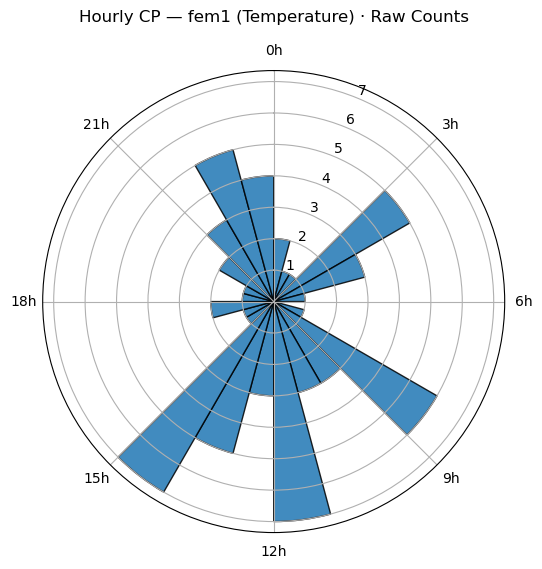

In [43]:
# Create a polar subplot
ax = plt.subplot(111, projection="polar")

# Draw bars for the chosen heights
bars = ax.bar(theta_bins, heights, width=bar_width, align="edge", edgecolor="k", alpha=0.85)

# Put 0 radians at the top (12 o’clock) and make angles increase clockwise (like a clock)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Label a few hour ticks to keep the plot clean
ax.set_xticks(2*np.pi*np.array([0,3,6,9,12,15,18,21])/24)
ax.set_xticklabels(["0h","3h","6h","9h","12h","15h","18h","21h"])

# Set a descriptive title reflecting normalization
ax.set_title(f"Hourly CP — {ANIMAL_COL} (Temperature) · {title_norm}", pad=16)

# Show the polar plot
plt.show()

Not uniform: CPs aren’t spread evenly across the 24 h—there are clear hot hours.

Strong peaks: The tallest bars are roughly around 12h (noon) and 15h (3 pm).

There’s also a secondary bump near 9h and another smaller one near 21h.

Lulls: Few CPs around 6h and 18h (early morning and early evening).

What it suggests: This animal’s temperature changepoints cluster at specific daytime hours, not randomly—good signal for the “two centers” idea.


## STEP 5 — Convert raw CP minutes to circular angles (for inference)
map minute-of-day to angle theta in [0, 2π) for fitting circular mixture.


In [29]:
# Comment: compute angles in radians for each CP minute
thetas = 2 * np.pi * (cp_minutes_all / 1440.0)

# Comment: wrap angles cleanly into [0, 2π)
thetas = np.mod(thetas, 2*np.pi)

# Comment: print how many angles we have
print(f"# Raw CP angles for {ANIMAL_COL}: {len(thetas)}")

# Raw CP angles for fem1: 68


# STEP 6 — 2-von-Mises mixture (custom EM)
fit two circular centers (means μ1, μ2) with concentrations (κ1, κ2) and weights; compute separation Δ.

Here’s the von Mises **mixture** in plain English, plus a simple “how to”:

#### What it is (simple)

* The **von Mises** distribution is the circular version of a normal (Gaussian): it models angles on a circle (0 to (2\pi) or 0–24 h).
* A **mixture** of von Mises means you assume your angles come from **two circular clumps** (two peaks), each with:

  * a **mean direction** (\mu_k) (the “center time” on the clock),
  * a **concentration** (\kappa_k) (how tight that clump is; bigger (\kappa) = sharper),
  * a **weight** (w_k) (how much of the data belong to that clump).

**K=2** components = **two centers of mass** for CP times within a day.

---

#### Why use it

* Your CP times clearly live on a **circle** (wrap at 24 h). Regular Gaussians don’t understand wrap-around; von Mises does.
* You want **two** preferred times (not one), and you want **numbers** (centers, tightness) rather than just eyeballing a plot.

---

### How to do it (practical steps)

1. **Get angles:** Convert each CP minute (m) to an angle (\theta = 2\pi \cdot m/1440).
2. **Initialize two clusters:**

   * Map each angle to a 2D point on the unit circle: ((\cos\theta, \sin\theta)).
   * Run **KMeans (K=2)** on those points to get a rough split.
3. **Estimate starting params (per cluster):**

   * **Mean direction (\mu):** circular mean = (\operatorname{atan2}(\sum\sin\theta,\ \sum\cos\theta)).
   * **Resultant length (R):** (R=\sqrt{(\sum\cos\theta)^2+(\sum\sin\theta)^2}/n).
   * **Concentration (\kappa):** convert (R\to\kappa) with a standard approximation (piecewise formula).
   * **Weight (w):** fraction of points in the cluster.
4. **Run EM (Expectation–Maximization):**

   * **E-step:** For each angle, compute its **responsibility** for each component using the von Mises **pdf** (from `scipy.stats.vonmises`), multiplied by the component weight. Normalize across the two components.
   * **M-step:** Re-estimate (w,\mu,\kappa) using those responsibilities as **weights** (same formulas as in step 3, but weighted).
   * **Repeat** E/M until the **log-likelihood** stops improving (tiny change).
5. **Read the results:**

   * (\mu_1,\mu_2) → your **two center times**. Convert radians back to hours if you like.
   * (\kappa_1,\kappa_2) → **clarity/tightness** of each center (higher = clearer).
   * (w_1,w_2) → how the data split between the two centers.
   * **Separation** (\Delta) = angular distance between (\mu_1) and (\mu_2) (report in hours).
6. **Sanity checks (optional but nice):**

   * Show that **2 components** fit better than **1** using **AIC/BIC** or held-out log-likelihood.
   * Plot your circular histogram and draw rays at (\mu_1,\mu_2).

---

### Tiny mental model

* Think of placing **two rubber bands** around the clock where CPs cluster the most. EM slides those bands to where they fit best and tightens them according to how concentrated the points are.

That’s it! Convert CPs → init with KMeans on ((\cos,\sin)) → EM with von Mises pdf → read off (\mu,\kappa,w) and the separation.


Here’s what each function does—and what **μ**, **κ**, and **w** mean—plain and simple.

#### Helper functions

* `circular_mean_and_R(angles)`

  * **What it does:** Takes a list/array of angles (in radians) and computes:

    * **μ (mu):** the **circular mean direction** (the average angle on a circle).
    * **R:** the **resultant length** (0–1) measuring how tightly the angles cluster around μ (1 = all identical; 0 = spread evenly).
  * **How:** Converts each angle to a unit vector ((\cos\theta,\sin\theta)), sums them, gets the direction (atan2) for μ and the normalized vector length for R.

* `kappa_from_R(R)`

  * **What it does:** Converts **R** (0–1) into **κ (kappa)**, the von Mises **concentration**.
  * **Meaning:** Higher **κ** ⇒ sharper/tighter peak; lower **κ** ⇒ flatter/wider spread.
  * **Why needed:** Von Mises is parameterized by **κ**, but it’s often easier to estimate **R** first; this gives you κ from R via standard approximations.

* `angdiff(a, b)`

  * **What it does:** Returns the **smallest absolute angular distance** between two angles **a** and **b** (in radians), always in ([0,\pi]).
  * **Why:** On a circle, the “distance” wraps around; this function handles the wrap correctly.

* `fit_vm_mix2(angles, ...)`

  * **What it does:** Fits a **2-component von Mises mixture** (i.e., assumes your angles come from two circular clusters).
  * **How (EM algorithm):**

    1. **Init** two clusters using KMeans on the unit-circle embedding ((\cos\theta,\sin\theta)).
    2. **E-step:** For each angle, compute its **responsibility** (soft assignment) for each component using the von Mises pdf (from `scipy.stats.vonmises`) times the component weight.
    3. **M-step:** Update each component’s **weight** (w_k), **mean direction** (μ_k), and **concentration** (κ_k) using those responsibilities.
    4. Repeat E/M until the **log-likelihood** stops improving (converges).
  * **Returns:** A dict with `mu` (length-2 array), `kappa` (length-2), `w` (length-2), and `resp` (N×2 responsibilities).

---

#### What are μ, κ, and w?

* **μ (mu):** The **mean direction** (center) of a von Mises component, in **radians** on ([0, 2π)).
  In your context: the **clock time** where a cluster of CPs tends to occur.

* **κ (kappa):** The **concentration** (tightness) of that component (unitless).
  Larger **κ** ⇒ CP times are **more tightly** clustered around μ (sharper peak).
  Smaller **κ** ⇒ CP times are **more spread out** (flatter peak).

* **w (weight):** The **mixture weight** for each component, between 0 and 1, and (w_1 + w_2 = 1).
  Interpreted as the **fraction of data** belonging to each “center.”

---

#### Quick intuition tying to your project

* You’re estimating **two centers of mass** of CP timing within a day: those are **μ₁** and **μ₂**.
* Their **clarity** is captured by **κ₁** and **κ₂** (bigger = clearer).
* How the CPs split between the two centers is **w₁** and **w₂**.
* The **separation** between centers is `angdiff(μ₁, μ₂)` (convert to hours if you like).


Processing of calculating means

For each time t in hours (0–24), compute the angle
theta = 2·pi·t/24.

Map to the unit circle point:
(x, y) = (cos(theta), sin(theta)).

Average across all points:
C̄ = mean(cos(thetaᵢ)), S̄ = mean(sin(thetaᵢ)).

The mean time (direction) is
mu = atan2(S̄, C̄) (in radians).
Convert to hours: mu_hours = mu · 24/(2·pi).

How concentrated the times are:
R̄ = sqrt(C̄² + S̄²) (near 1 = tight, near 0 = spread out).

A circular “std dev”:
s_circ = sqrt(−2 · ln(R̄)) (radians).
In hours: s_hours = s_circ · 24/(2·pi).

In [30]:
# Comment: helper to compute circular mean and resultant length R
def circular_mean_and_R(angles):
    # Comment: sum unit vectors on the circle
    C = np.cos(angles).sum()
    S = np.sin(angles).sum()
    # Comment: mean direction (wrapped to [0, 2π))
    mu = (np.arctan2(S, C)) % (2*np.pi)
    # Comment: resultant length normalized by n
    R = np.sqrt(C**2 + S**2) / max(len(angles), 1)
    # Comment: return both
    return mu, R

In [31]:
# Comment: approximate kappa from resultant length (standard approximation)
def kappa_from_R(R):
    # Comment: clamp R to avoid numerical issues
    R = float(np.clip(R, 0.0, 0.999999))
    # Comment: piecewise approximation (Banerjee)
    if R < 0.53:
        return max(2*R + R**3 + 5*(R**5)/6, 1e-6)
    elif R < 0.85:
        return max(-0.4 + 1.39*R + 0.43/(1 - R), 1e-6)
    else:
        return max(1/(R**3 - 4*R**2 + 3*R), 1e-6)

In [32]:
# Comment: minimal angular distance (absolute) between angles a and b
def angdiff(a, b):
    # Comment: wrap diff to [-π, π]
    diff = (a - b + np.pi) % (2*np.pi) - np.pi
    # Comment: return absolute distance
    return np.abs(diff)

In [33]:
# Comment: fit a 2-component von Mises mixture via EM
def fit_vm_mix2(angles, max_iter=200, tol=1e-6, random_state=0):
    # Comment: reshape to column for clustering init
    X = np.column_stack([np.cos(angles), np.sin(angles)])
    # Comment: k-means init on the unit circle embedding
    km = KMeans(n_clusters=2, n_init=10, random_state=random_state).fit(X)
    # Comment: initial responsibilities from cluster labels
    z = np.zeros((len(angles), 2), float)
    z[np.arange(len(angles)), km.labels_] = 1.0
    # Comment: EM loop
    prev_ll = -np.inf
    for it in range(max_iter):
        # Comment: M-step: update weights
        w = z.mean(axis=0)
        # Comment: avoid degenerate weights
        w = np.clip(w, 1e-6, 1-1e-6)
        w = w / w.sum()
        # Comment: update means and kappas per component
        mu = np.zeros(2)
        kappa = np.zeros(2)
        for k in range(2):
            # Comment: weighted mean direction
            Ck = np.sum(z[:, k] * np.cos(angles))
            Sk = np.sum(z[:, k] * np.sin(angles))
            mu[k] = (np.arctan2(Sk, Ck)) % (2*np.pi)
            # Comment: weighted resultant length per point
            Rk = np.sqrt(Ck**2 + Sk**2) / max(z[:, k].sum(), 1e-9)
            kappa[k] = kappa_from_R(Rk)
        # Comment: E-step: recompute responsibilities via component likelihoods
        # Comment: compute log-likelihoods per component for each angle
        logp = np.zeros((len(angles), 2))
        for k in range(2):
            # Comment: von Mises log pdf up to constant using scipy (exact)
            logp[:, k] = np.log(w[k] + 1e-12) + vonmises.logpdf(angles, kappa[k], loc=mu[k])
        # Comment: log-sum-exp for normalization
        maxlog = logp.max(axis=1, keepdims=True)
        resp = np.exp(logp - maxlog)
        resp = resp / resp.sum(axis=1, keepdims=True)
        # Comment: update responsibilities
        z = resp
        # Comment: compute total log-likelihood to check convergence
        ll = (maxlog + np.log(resp.sum(axis=1, keepdims=True))).sum()  # equals logsumexp sum
        # Comment: check convergence on improvement
        if np.abs(ll - prev_ll) < tol:
            break
        prev_ll = ll
    # Comment: return parameters and soft assignments
    return {"mu": mu, "kappa": kappa, "w": w, "resp": z}

In [34]:
# Comment: fit the 2-component mixture on the CP angles
mix = fit_vm_mix2(thetas, max_iter=300, tol=1e-6, random_state=42)


In [35]:
# Comment: extract parameters
mu1, mu2 = mix["mu"]
kappa1, kappa2 = mix["kappa"]
w1, w2 = mix["w"]

In [36]:
# Comment: compute separation Δ (in radians) and also in hours for intuition
delta_rad = angdiff(mu1, mu2)
delta_hours = (24.0 * delta_rad) / (2*np.pi)


In [37]:
# Comment: print parameter summary
print(f"μ1={mu1:.3f} rad, κ1={kappa1:.3f}, w1={w1:.3f}")
print(f"μ2={mu2:.3f} rad, κ2={kappa2:.3f}, w2={w2:.3f}")
print(f"Separation Δ = {delta_rad:.3f} rad ≈ {delta_hours:.2f} hours")

μ1=6.262 rad, κ1=1.173, w1=0.485
μ2=3.120 rad, κ2=2.422, w2=0.515
Separation Δ = 3.141 rad ≈ 12.00 hours


### STEP 7 — Overlay the two centers on the polar histogram (visual sanity check)
draw rays at μ1 and μ2 on top of the hourly rose plot.

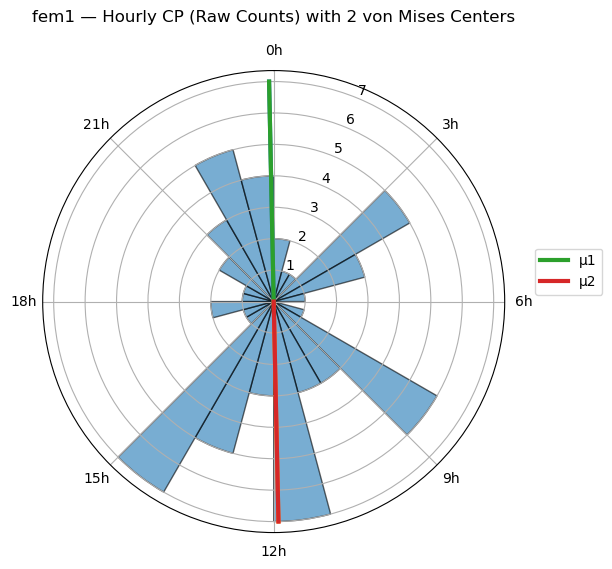

In [45]:
# Comment: re-plot the hourly polar bars for context using the chosen heights
ax = plt.subplot(111, projection="polar")

# Comment: draw bars with the chosen normalization
ax.bar(theta_bins, heights, width=bar_width, align="edge", edgecolor="k", alpha=0.6)

# Comment: set polar orientation (0 at top; clockwise like a clock)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Comment: label selected hour ticks to keep plot clean
ax.set_xticks(2*np.pi*np.array([0,3,6,9,12,15,18,21])/24)
ax.set_xticklabels(["0h","3h","6h","9h","12h","15h","18h","21h"])

# Comment: title reflects animal and normalization
ax.set_title(f"{ANIMAL_COL} — Hourly CP ({title_norm}) with 2 von Mises Centers", pad=16)

# Comment: compute max radius from the bars so rays reach the bar tops
max_r = max(np.max(heights), 1e-9)

# Comment: plot rays at μ1 and μ2 from center to max radius
ax.plot([mu1, mu1], [0, max_r], linewidth=3)
ax.plot([mu2, mu2], [0, max_r], linewidth=3)
ax.plot([mu1, mu1], [0, max_r], linewidth=3, label="μ1")
ax.plot([mu2, mu2], [0, max_r], linewidth=3, label="μ2")
ax.legend(loc="lower left", bbox_to_anchor=(1.05, 0.5))
# Comment: show the figure
plt.show()

The blue bars are this animal’s hourly changepoint (CP) counts (raw). You can see clear activity at ~12–15 h and some night-time activity near ~0–2 h and ~21 h.

The two vertical rays are the fitted von Mises centers:

μ₁ (green) ≈ 0 h (around midnight).

μ₂ (red) ≈ 12 h (around noon).

The centers are roughly opposite on the clock (~12 h apart) → a bimodal pattern across the day, consistent with two preferred CP times.

Visually, the noon cluster lines up with the tallest bars (stronger mode). The midnight cluster matches a secondary night-time bump.

This matches “two centres of mass” idea. To quantify “clarity,” use the fitted κ₁, κ₂ (tightness) and the separation Δ (in hours). If you anchor by lights-on, these centers will rotate but the two-mode structure should remain.

# Comparing plots for all male and female (temperature)

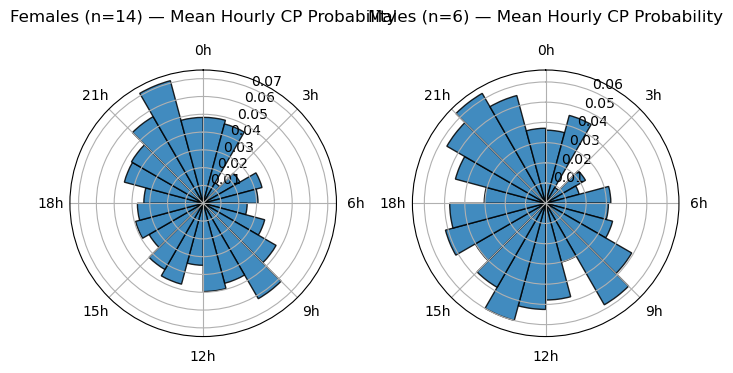

In [46]:
# ============================
# GROUP POLAR PLOTS (Females vs Males) — Temperature CP timing
# Per-animal CPs → per-animal hourly distribution (probability per CP) → average across animals within sex
# ============================

# Comment: import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ruptures as rpt

# Comment: set matplotlib aesthetics
plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["axes.grid"] = True

# Comment: set CSV paths (edit if filenames differ)
female_csv_path = "mice data.xlsx - FemTemp.csv"     # change if needed
male_csv_path   = "mice data.xlsx - MaleTemp.csv"    # change if needed

# Comment: set ruptures parameters (same as before; tune if needed)
CP_MODEL = "rbf"    # 'rbf' is flexible; try 'normal'/'l2' as sensitivity
MIN_SIZE = 30       # minimum segment length in minutes
PENALTY  = 12       # larger → fewer CPs

# Comment: constant: minutes per day
DAY_MIN = 1440

# Comment: helper to compute per-animal hourly CP histogram (probability per CP) from a time series
def per_animal_hourly_prob(temp_series):
    # Comment: temp_series must be 1D numpy array of length n_days*1440, ordered by minute
    n = len(temp_series)
    # Comment: compute number of full days
    n_days = n // DAY_MIN
    # Comment: assert full days
    assert n_days * DAY_MIN == n, "Series length must be a multiple of 1440 minutes."
    # Comment: prepare a list to collect CP minutes across all days
    cp_minutes = []
    # Comment: loop over days
    for d in range(n_days):
        # Comment: slice this day's 1440-min window
        x = temp_series[d*DAY_MIN:(d+1)*DAY_MIN].astype(float)
        # Comment: run PELT with chosen model and min segment size
        algo = rpt.Pelt(model=CP_MODEL, min_size=MIN_SIZE).fit(x)
        # Comment: get changepoints via penalty; these are 1-based end indices
        cps = algo.predict(pen=PENALTY)
        # Comment: convert to 0-based and drop terminal index (length of day)
        day_len = len(x)
        cutpoints = [idx for idx in cps if idx < day_len]
        # Comment: extend the list with minute-of-day CPs
        cp_minutes.extend(cutpoints)
    # Comment: if no CPs were found, return a flat 24-vector of zeros to avoid errors
    if len(cp_minutes) == 0:
        return np.zeros(24, dtype=float)
    # Comment: map each CP minute to hour bin 0..23
    cp_hours = (np.array(cp_minutes) // 60).astype(int)
    # Comment: count per hour
    counts = np.bincount(cp_hours, minlength=24)
    # Comment: normalize to probability per CP (sum = 1 for this animal)
    prob = counts / counts.sum()
    # Comment: return the per-animal hourly probability vector
    return prob

# Comment: helper to process a whole CSV (one sex), returning the group-mean hourly profile
def process_sex(csv_path, col_prefix):
    # Comment: read the CSV
    df = pd.read_csv(csv_path)
    # Comment: extract the minute counter and use it to sort just in case
    t = df["time (min)"].astype(int).values
    # Comment: find animal columns by prefix (e.g., 'fem' or 'male')
    animal_cols = [c for c in df.columns if c.lower().startswith(col_prefix)]
    # Comment: sort columns consistently
    animal_cols = sorted(animal_cols, key=lambda x: int(''.join(filter(str.isdigit, x)) or 0))
    # Comment: list to store per-animal 24-dim probability vectors
    per_animal_probs = []
    # Comment: iterate animals
    for col in animal_cols:
        # Comment: pull 1D series (assumed minute-order)
        series = df[col].astype(float).values
        # Comment: compute the per-animal hourly probability vector
        prob = per_animal_hourly_prob(series)
        # Comment: append to the list
        per_animal_probs.append(prob)
    # Comment: stack into array (n_animals x 24); handle edge case of zero animals
    if len(per_animal_probs) == 0:
        return None, []
    M = np.vstack(per_animal_probs)  # shape: (n_animals, 24)
    # Comment: compute group mean profile across animals (each animal weighted equally)
    mean_profile = M.mean(axis=0)
    # Comment: also compute group std if you want later (not used in bars)
    std_profile = M.std(axis=0)
    # Comment: return mean profile and the list of columns processed
    return mean_profile, animal_cols

# Comment: try processing females; will raise if file path is wrong
female_mean, female_animals = process_sex(female_csv_path, col_prefix="fem")

# Comment: try processing males; if file is missing or empty, set to None
male_mean, male_animals = (None, [])
try:
    male_mean, male_animals = process_sex(male_csv_path, col_prefix="male")
except Exception as e:
    # Comment: if reading male file fails, note it in the printout and continue with females only
    print(f"[Info] Could not process male file: {e}")

# Comment: prepare polar bin geometry
theta_bins = 2 * np.pi * (np.arange(24) / 24.0)
bar_width = 2 * np.pi / 24.0

# Comment: plot FEMALES group polar bars if available
if female_mean is not None:
    # Comment: create polar subplot
    ax = plt.subplot(121, projection="polar")
    # Comment: draw bars using per-animal-mean probability
    ax.bar(theta_bins, female_mean, width=bar_width, align="edge", edgecolor="k", alpha=0.85)
    # Comment: set polar clock orientation
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    # Comment: tick labels every 3h
    ax.set_xticks(2*np.pi*np.array([0,3,6,9,12,15,18,21])/24)
    ax.set_xticklabels(["0h","3h","6h","9h","12h","15h","18h","21h"])
    # Comment: title includes number of animals
    ax.set_title(f"Females (n={len(female_animals)}) — Mean Hourly CP Probability", pad=16)

# Comment: plot MALES group polar bars if available
if male_mean is not None:
    # Comment: create polar subplot (second panel)
    ax2 = plt.subplot(122, projection="polar")
    # Comment: draw bars for males
    ax2.bar(theta_bins, male_mean, width=bar_width, align="edge", edgecolor="k", alpha=0.85)
    # Comment: set polar orientation
    ax2.set_theta_zero_location("N")
    ax2.set_theta_direction(-1)
    # Comment: tick labels every 3h
    ax2.set_xticks(2*np.pi*np.array([0,3,6,9,12,15,18,21])/24)
    ax2.set_xticklabels(["0h","3h","6h","9h","12h","15h","18h","21h"])
    # Comment: title with number of animals
    ax2.set_title(f"Males (n={len(male_animals)}) — Mean Hourly CP Probability", pad=16)

# Comment: adjust layout to avoid overlap
plt.tight_layout()
# Comment: show the figure(s)
plt.show()


Simple summary of the normalization:

Per mouse: Convert hourly CP counts into a probability over 24 hours (each mouse’s bars sum to 1).

Across mice (within a sex): Take the average of those per-mouse probability vectors.

This makes each mouse contribute equally and focuses the plots on timing patterns (when CPs occur), not on how many CPs or how many mice there are.

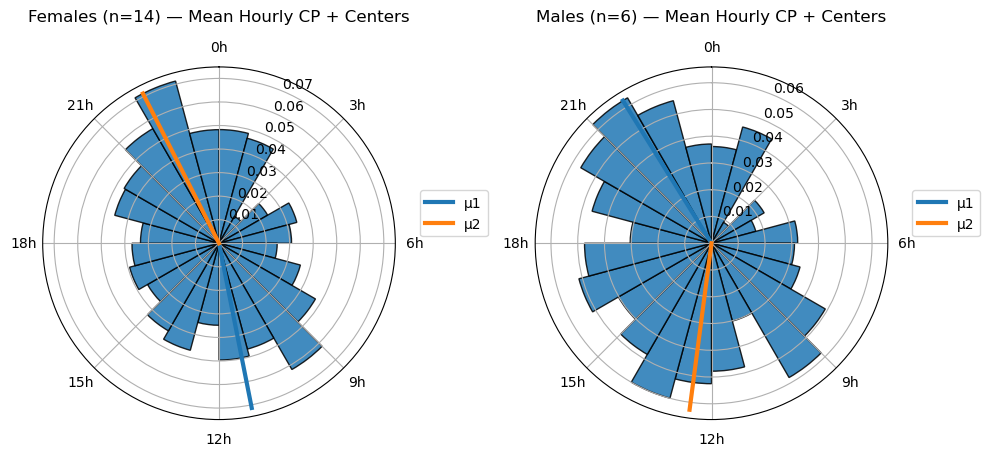

Females:
  μ (hours) = 11.25, 22.20
  κ = 0.58, 2.60
  w = 0.71, 0.29
  Separation Δ ≈ 10.95 h
Males:
  μ (hours) = 21.88, 12.50
  κ = 3.21, 0.57
  w = 0.22, 0.78
  Separation Δ ≈ 9.38 h


In [ ]:
# ============================
# Add two von Mises centers (μ1, μ2) per sex and overlay on the group polar plots
# ============================

# Comment: import libs used below
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ruptures as rpt

# Comment: constants (reuse your earlier ones)
DAY_MIN = 1440            # minutes per day
CP_MODEL = CP_MODEL       # reuse from above (e.g., "rbf")
MIN_SIZE = MIN_SIZE       # reuse from above (e.g., 30)
PENALTY  = PENALTY        # reuse from above (e.g., 12)

# Comment: helper — collect ALL CP angles (in radians) for one animal time series
def cp_angles_for_series(temp_series):
    # Comment: ensure full days
    n = len(temp_series)
    assert n % DAY_MIN == 0, "Series must be a multiple of 1440 minutes."
    n_days = n // DAY_MIN
    # Comment: list of minute-of-day CPs
    cp_minutes = []
    # Comment: loop per day and detect CPs
    for d in range(n_days):
        x = temp_series[d*DAY_MIN:(d+1)*DAY_MIN].astype(float)
        algo = rpt.Pelt(model=CP_MODEL, min_size=MIN_SIZE).fit(x)
        cps = algo.predict(pen=PENALTY)
        day_len = len(x)
        cutpoints = [idx for idx in cps if idx < day_len]
        cp_minutes.extend(cutpoints)
    # Comment: convert minutes to angles θ in [0, 2π)
    thetas = 2*np.pi*(np.array(cp_minutes)/DAY_MIN)
    thetas = np.mod(thetas, 2*np.pi)
    return thetas

# Comment: helper — pool CP angles across all animals in a CSV with a given prefix (e.g., 'fem', 'male')
def pooled_angles_for_sex(csv_path, col_prefix):
    # Comment: read the CSV
    df = pd.read_csv(csv_path)
    # Comment: get animal columns by prefix and sort numerically
    cols = [c for c in df.columns if c.lower().startswith(col_prefix)]
    cols = sorted(cols, key=lambda x: int(''.join(filter(str.isdigit, x)) or 0))
    # Comment: pool angles from all animals
    pooled = []
    for col in cols:
        series = df[col].astype(float).values
        thetas = cp_angles_for_series(series)
        pooled.append(thetas)
    # Comment: concatenate all animals' angles for this sex
    if len(pooled) == 0:
        return np.array([])
    return np.concatenate(pooled), cols

# Comment: collect pooled CP angles for Females and Males
female_angles, female_animals = pooled_angles_for_sex(female_csv_path, "fem")
male_angles,   male_animals   = pooled_angles_for_sex(male_csv_path,   "male")

# Comment: fit 2-von-Mises mixtures using your earlier EM helper
female_mix = fit_vm_mix2(female_angles, max_iter=300, tol=1e-6, random_state=42) if female_angles.size else None
male_mix   = fit_vm_mix2(male_angles,   max_iter=300, tol=1e-6, random_state=42) if male_angles.size   else None

# Comment: prepare polar bin geometry and make the bar heights from the existing mean profiles
theta_bins = 2 * np.pi * (np.arange(24) / 24.0)
bar_width  = 2 * np.pi / 24.0

# Comment: recompute the per-sex mean hourly probabilities (so we can replot bars and overlay μ)
def per_animal_hourly_prob(temp_series):
    # Comment: same helper as before (counts → prob per CP)
    n = len(temp_series); assert n % DAY_MIN == 0
    n_days = n // DAY_MIN
    cp_minutes = []
    for d in range(n_days):
        x = temp_series[d*DAY_MIN:(d+1)*DAY_MIN].astype(float)
        algo = rpt.Pelt(model=CP_MODEL, min_size=MIN_SIZE).fit(x)
        cps = algo.predict(pen=PENALTY)
        day_len = len(x)
        cutpoints = [idx for idx in cps if idx < day_len]
        cp_minutes.extend(cutpoints)
    if len(cp_minutes) == 0:
        return np.zeros(24, dtype=float)
    cp_hours = (np.array(cp_minutes)//60).astype(int)
    counts = np.bincount(cp_hours, minlength=24)
    return counts / counts.sum()

def mean_profile_for_sex(csv_path, prefix):
    df = pd.read_csv(csv_path)
    cols = [c for c in df.columns if c.lower().startswith(prefix)]
    cols = sorted(cols, key=lambda x: int(''.join(filter(str.isdigit, x)) or 0))
    profiles = []
    for col in cols:
        profiles.append(per_animal_hourly_prob(df[col].astype(float).values))
    return (np.vstack(profiles).mean(axis=0), cols) if profiles else (None, [])

female_mean, female_animals2 = mean_profile_for_sex(female_csv_path, "fem")
male_mean,   male_animals2   = mean_profile_for_sex(male_csv_path,   "male")

# Comment: plot FEMALES with μ1/μ2 rays if available
plt.figure(figsize=(10,5))
ax = plt.subplot(121, projection="polar")
if female_mean is not None:
    ax.bar(theta_bins, female_mean, width=bar_width, align="edge", edgecolor="k", alpha=0.85)
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    ax.set_xticks(2*np.pi*np.array([0,3,6,9,12,15,18,21])/24)
    ax.set_xticklabels(["0h","3h","6h","9h","12h","15h","18h","21h"])
    ax.set_title(f"Females (n={len(female_animals)}) — Mean Hourly CP + Centers", pad=14)
    if female_mix is not None:
        mu1, mu2 = female_mix["mu"]; max_r = max(female_mean.max(), 1e-9)
        ax.plot([mu1, mu1], [0, max_r], linewidth=3, label="μ1")
        ax.plot([mu2, mu2], [0, max_r], linewidth=3, label="μ2")
        ax.legend(loc="lower left", bbox_to_anchor=(1.05, 0.5))


# Comment: plot MALES with μ1/μ2 rays if available
ax2 = plt.subplot(122, projection="polar")
if male_mean is not None:
    ax2.bar(theta_bins, male_mean, width=bar_width, align="edge", edgecolor="k", alpha=0.85)
    ax2.set_theta_zero_location("N"); ax2.set_theta_direction(-1)
    ax2.set_xticks(2*np.pi*np.array([0,3,6,9,12,15,18,21])/24)
    ax2.set_xticklabels(["0h","3h","6h","9h","12h","15h","18h","21h"])
    ax2.set_title(f"Males (n={len(male_animals)}) — Mean Hourly CP + Centers", pad=14)
    if male_mix is not None:
        mu1, mu2 = male_mix["mu"]; max_r2 = max(male_mean.max(), 1e-9)
        ax2.plot([mu1, mu1], [0, max_r2], linewidth=3, label="μ1")
        ax2.plot([mu2, mu2], [0, max_r2], linewidth=3, label="μ2")
        ax2.legend(loc="lower left", bbox_to_anchor=(1.05, 0.5))


# Comment: finish layout and show
plt.tight_layout()
plt.show()

# Comment: print numeric parameters for reporting (μ in hours, κ, w, and separation Δ)
def print_mix(label, mix):
    if mix is None: 
        print(f"{label}: no mixture fit")
        return
    mu = mix["mu"]; kappa = mix["kappa"]; w = mix["w"]
    delta_rad = angdiff(mu[0], mu[1]); delta_h = 24*delta_rad/(2*np.pi)
    mu_h = (24*np.array(mu)/(2*np.pi)) % 24
    print(f"{label}:")
    print(f"  μ (hours) = {mu_h[0]:.2f}, {mu_h[1]:.2f}")
    print(f"  κ = {kappa[0]:.2f}, {kappa[1]:.2f}")
    print(f"  w = {w[0]:.2f}, {w[1]:.2f}")
    print(f"  Separation Δ ≈ {delta_h:.2f} h")

print_mix("Females", female_mix)
print_mix("Males",   male_mix)


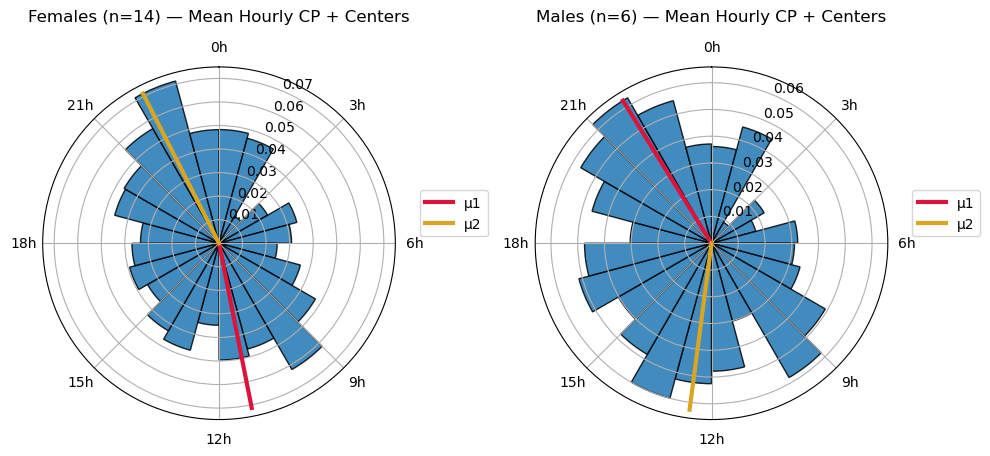

In [49]:
# ==== GROUP PLOTS with high-contrast μ rays (crimson / goldenrod) ====
plt.figure(figsize=(10, 5))

# --- FEMALES ---
ax = plt.subplot(121, projection="polar")
if female_mean is not None:
    # bars
    ax.bar(theta_bins, female_mean, width=bar_width, align="edge", edgecolor="k", alpha=0.85)
    # clock style
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    ax.set_xticks(2*np.pi*np.array([0,3,6,9,12,15,18,21])/24)
    ax.set_xticklabels(["0h","3h","6h","9h","12h","15h","18h","21h"])
    ax.set_title(f"Females (n={len(female_animals)}) — Mean Hourly CP + Centers", pad=14)

    # μ rays (use distinct colors)
    if female_mix is not None:
        f_mu1, f_mu2 = female_mix["mu"]
        max_r_f = max(float(np.max(female_mean)), 1e-9)
        ax.plot([f_mu1, f_mu1], [0, max_r_f], color="crimson",   linewidth=3, zorder=5, label="μ1")
        ax.plot([f_mu2, f_mu2], [0, max_r_f], color="goldenrod", linewidth=3, zorder=5, label="μ2")
        ax.legend(loc="lower left", bbox_to_anchor=(1.05, 0.5))

# --- MALES ---
ax2 = plt.subplot(122, projection="polar")
if male_mean is not None:
    # bars
    ax2.bar(theta_bins, male_mean, width=bar_width, align="edge", edgecolor="k", alpha=0.85)
    # clock style
    ax2.set_theta_zero_location("N"); ax2.set_theta_direction(-1)
    ax2.set_xticks(2*np.pi*np.array([0,3,6,9,12,15,18,21])/24)
    ax2.set_xticklabels(["0h","3h","6h","9h","12h","15h","18h","21h"])
    ax2.set_title(f"Males (n={len(male_animals)}) — Mean Hourly CP + Centers", pad=14)

    # μ rays (distinct colors)
    if male_mix is not None:
        m_mu1, m_mu2 = male_mix["mu"]
        max_r_m = max(float(np.max(male_mean)), 1e-9)
        ax2.plot([m_mu1, m_mu1], [0, max_r_m], color="crimson",   linewidth=3, zorder=5, label="μ1")
        ax2.plot([m_mu2, m_mu2], [0, max_r_m], color="goldenrod", linewidth=3, zorder=5, label="μ2")
        ax2.legend(loc="lower left", bbox_to_anchor=(1.05, 0.5))

plt.tight_layout()
plt.show()


In [50]:
print_mix("Females", female_mix)
print_mix("Males",   male_mix)

Females:
  μ (hours) = 11.25, 22.20
  κ = 0.58, 2.60
  w = 0.71, 0.29
  Separation Δ ≈ 10.95 h
Males:
  μ (hours) = 21.88, 12.50
  κ = 3.21, 0.57
  w = 0.22, 0.78
  Separation Δ ≈ 9.38 h


Quick takeaways

Bimodal timing in both sexes.
Centers land near ~12 h (mid-day) and ~22 h (late evening).

Weights (w): which mode is bigger?

Females: 
𝑤
≈
[
0.71
,
  
0.29
]
w≈[0.71,0.29] → more CPs mid-day than late evening.

Males: 
𝑤
≈
[
0.22
,
  
0.78
]
w≈[0.22,0.78] → more CPs mid-day as well (the 0.78 component is the mid-day one in your fit).

Clarity (κ): which mode is tighter?

Females: evening peak is sharper (
𝜅
≈
2.60
κ≈2.60) than mid-day (
𝜅
≈
0.58
κ≈0.58).

Males: same story—evening peak is sharper (
𝜅
≈
3.21
κ≈3.21) than mid-day (
𝜅
≈
0.57
κ≈0.57).
(So: evening = narrower/clearer, mid-day = broader.)

Separation: ~11 h (F) and 9.4 h (M) → centers are almost half a day apart.

Why do μ₁ and μ₂ look “reversed” across sexes?

Mixture models don’t attach semantic labels to components—the ordering is arbitrary. EM can return the two modes in any order (by chance, init, or tiny likelihood differences). That’s why “μ₁ is red” corresponds to the evening mode in one plot and to mid-day in the other.

#### Questions 

1. **Do males and females differ in CP volume per animal?**

   * *Test:* Mann–Whitney on **total CPs per animal**.
   * *Interpretation:* If p is small, one sex tends to have **more CPs** per mouse.

2. **Is CP timing more/less concentrated in one sex?**

   * *Test:* Mann–Whitney on **(\kappa_{\text{evening}})** and on **(\kappa_{\text{midday}})** (per-animal κ after aligning components).
   * *Interpretation:* **Higher κ** ⇒ **tighter clustering** (clearer daily center). Small p indicates a sex difference in **clarity** at that center.

3. *** Are mean κ differences robust by resampling?**

   * *Test:* **Permutation tests** on mean κ differences (evening, mid-day).
   * *Interpretation:* Resampled p-values that agree with Mann–Whitney strengthen confidence; discrepancies flag distributional quirks.


### What this analysis code does (and why)

**Goal:** Test two hypotheses about changepoint (CP) timing in mouse temperature:

1. **Volume:** Do males and females differ in the **number of CPs per animal**?
2. **Clarity:** Are CP times **more tightly clustered** (higher concentration κ) in one sex than the other, **at each of the two daily centers** (evening vs mid-day)?

---

#### Pipeline overview

1. **Detect CPs per day, per animal.**

2. **(A) Total CPs per animal.**

3. **Convert CP minutes → circular angles.**

4. **Fit a 2-von-Mises mixture per animal.**

5. **(B) Clarity (κ) comparison across sexes.**

   * Extract **(\kappa_{\text{evening}})** and **(\kappa_{\text{midday}})** per animal.
   * Compare the **distributions** of these κ’s between **females vs males**.

6. **Statistical tests reported.**

   * **Mann–Whitney U tests** (two-sided) for:

     * total CPs per animal (Fem vs Male),
     * evening κ (Fem vs Male),
     * mid-day κ (Fem vs Male).
   * **Optional permutation tests** for mean κ differences provide a non-parametric, resampling-based p-value as a robustness check.

---
#### Why use **Mann–Whitney U**?

* It’s a **non-parametric** test that compares **distributions** (medians/ranks) **without assuming normality** or equal variances—appropriate for count data (total CPs) and **bounded, skew-prone** parameters like κ.
* Sample sizes per sex can be **unequal**; Mann–Whitney handles that cleanly.
* It answers: *Is one group systematically larger than the other in rank terms?*—exactly what we want when distributions may not be Gaussian.



Here’s the read:

### 1) CP **volume per animal**

* **Males have more CPs per mouse.**
  Females: median **84**, mean **85.9** (n=14)
  Males: median **112**, mean **111.3** (n=6)
  **Mann–Whitney p = 0.0082** → statistically significant difference.
* Plain English: a typical male mouse had **~25–30 more CPs** across the 8 days than a typical female.

### 2) CP **clarity (concentration κ) at the two daily centers**

* **Evening center (~22h):** medians → Fem **1.31** vs Male **2.54**; **p = 0.239**
  → Males look **sharper** on median, but **not statistically significant** with current n.
* **Mid-day center (~12h):** medians → Fem **1.42** vs Male **1.01**; **p = 0.239**
  → Females look **sharper** on median, but **not statistically significant**.
* **Permutation (means):** evening **p = 0.0865** (suggestive but not < 0.05), mid-day **p = 0.362** (no signal).

### Bottom line

* **Yes, males show a higher CP count per animal** over 8 days (robust difference).
* **No clear evidence** that one sex has **tighter timing** than the other at either center with this sample; any apparent sharpness differences could be noise.

### Caveats / next steps

* **Small n for males (n=6)** → low power for κ tests. Consider more animals or report **effect sizes** (e.g., Cliff’s delta) and **bootstrap CIs** for κ.
* Ensure component **alignment rule** (evening vs mid-day) is applied consistently (already done).
* Try **sensitivity** to CP detection params (`min_size`, `penalty`, cost model) and to **clock anchor** (midnight vs lights-on). If results hold, confidence increases.
* Consider per-animal **clarity composite** (e.g., ((\kappa_{\text{even}}+\kappa_{\text{mid}})/2)) and test that as well.
